In [1]:
import anndata
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from tqdm import tqdm

In [2]:
adata = sc.read_h5ad("/storage/pancellflow/data/srivatsan20_sciplex3_w_emb.h5ad", backed="r")

In [3]:
adata = adata[adata.obs["cell_line"] != "NA"].to_memory()

In [4]:
control = adata[adata.obs["pert_compound"] == "control"]
treated = adata[adata.obs["pert_compound"] != "control"]
#treated = treated[treated.obs["cell_line"] != "NA"]
print(treated.obs["cell_line"].value_counts())

print(f"Control cells: {control.n_obs}")
print(f"Treated cells: {treated.n_obs}")

MCF7     323651
A549     228359
K-562    163076
Name: cell_line, dtype: int64
Control cells: 17578
Treated cells: 715086


In [5]:
print(control.obs["cell_line"].value_counts())
print(treated.obs["cell_line"].value_counts())

MCF7     7786
A549     5857
K-562    3935
Name: cell_line, dtype: int64
MCF7     323651
A549     228359
K-562    163076
Name: cell_line, dtype: int64


In [6]:
print(adata.obs.columns.tolist())

['pert_target', 'pert_compound', 'pert_dose', 'pert_time', 'organism', 'cell_line', 'cell_type', 'disease', 'tissue_type', 'tissue', 'assay', 'suspension_type', 'donor_id', 'sex', 'self_reported_ethnicity', 'development_stage', 'pert_name', 'pert_type', 'ncounts', 'well', 'plate', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'pathway', 'dose_unit', 'cancer', 'drug_org', 'drug_0', 'drug_1']


In [7]:
adata.obs[["cell_line", "pert_compound", "dose_value", "time", "plate", "well"]].drop_duplicates().head(10)

,cell_line,pert_compound,dose_value,time,plate,well
A01_E09_RT_BC_100_Lig_BC_147,MCF7,TAK-901,10000.0,24.0,plate44,plate6_A9
A01_E09_RT_BC_100_Lig_BC_186,MCF7,AG-490,10.0,24.0,plate46,plate8_H3
A01_E09_RT_BC_100_Lig_BC_196,MCF7,abexinostat,1000.0,24.0,plate41,plate3_C2
A01_E09_RT_BC_100_Lig_BC_213,A549,alisertib,1000.0,72.0,plate51,plate9_E3
A01_E09_RT_BC_100_Lig_BC_220,K-562,busulfan,10000.0,24.0,plate30,plate8_H10
A01_E09_RT_BC_100_Lig_BC_227,MCF7,Obatoclax,100.0,24.0,plate47,plate9_G9
A01_E09_RT_BC_100_Lig_BC_245,A549,Enzastaurin,1000.0,24.0,plate39,plate9_C3
A01_E09_RT_BC_100_Lig_BC_254,MCF7,BMS-265246,100.0,24.0,plate47,plate9_H11
A01_E09_RT_BC_100_Lig_BC_289,K-562,UNC0379,1000.0,24.0,plate27,plate5_A6
A01_E09_RT_BC_100_Lig_BC_306,A549,Raltitrexed,10.0,24.0,plate40,plate10_D6


In [8]:
cell_line = "MCF7"
drug = "ruxolitinib"

initial = adata.obs[
    (adata.obs["cell_line"] == cell_line) & 
    (adata.obs["pert_compound"] == "control")
]

In [9]:
adata.obs.columns

Index(['pert_target', 'pert_compound', 'pert_dose', 'pert_time', 'organism',
       'cell_line', 'cell_type', 'disease', 'tissue_type', 'tissue', 'assay',
       'suspension_type', 'donor_id', 'sex', 'self_reported_ethnicity',
       'development_stage', 'pert_name', 'pert_type', 'ncounts', 'well',
       'plate', 'replicate', 'time', 'dose_value', 'pathway_level_1',
       'pathway_level_2', 'pathway', 'dose_unit', 'cancer', 'drug_org',
       'drug_0', 'drug_1'],
      dtype='object')

In [11]:
ic50_df = pd.read_csv("/storage/pancellflow/results/ic50_data.csv")

adata_drugs = set(treated.obs["pert_compound"].str.lower().str.strip().unique())
ic50_drugs = set(ic50_df["drug"].str.lower().str.strip().unique())

common = adata_drugs & ic50_drugs
print(f"Common drugs: {len(common)} / {len(adata_drugs)}")
print(common)

Common drugs: 82 / 180
{'celecoxib', 'sorafenib', 'panobinostat', 'sgi-1776', 'ruxolitinib', 'jnj-7706621', 'pfi-1', 'daphnetin', 'cediranib', 'pelitinib', 'avagacestat', 'fluorouracil', 'tofacitinib', 'dacinostat', 'sirtinol', 'maraviroc', 'curcumin', 'disulfiram', 'pha-680632', 'dasatinib', 'tanespimycin', 'belinostat', 'vandetanib', '2-methoxyestradiol', 'quercetin', 'nilotinib', 'prednisone', 'alvespimycin', 'capecitabine', 'trametinib', 'tozasertib', 'alisertib', 'hesperadin', 'mocetinostat', 'whi-p154', 'momelotinib', 'barasertib', 'aminoglutethimide', 'carmofur', 'rigosertib', 'enmd-2076', 'zileuton', 'fulvestrant', 'raltitrexed', 'thalidomide', 'toremifene', 'azacitidine', 'tazemetostat', 'thiotepa', 'fasudil', 'pd173074', 'pirarubicin', 'ar-42', 'regorafenib', 'rucaparib', 'ki8751', 'danusertib', 'veliparib', 'entinostat', 'nintedanib', 'filgotinib', 'amisulpride', 'tacedinaline', 'crizotinib', 'bms-754807', 'lenalidomide', 'navitoclax', 'cudc-101', 'costunolide', 'busulfan', 

In [17]:
# --- Get HVGs and fit PCA on subsample ---
N_SAMPLE = 40000
rng = np.random.default_rng(42)
idx = rng.choice(adata.n_obs, N_SAMPLE, replace=False)
adata.X = np.nan_to_num(adata.X, nan=0.0, posinf=0.0, neginf=0.0)
adata_sub = adata[idx].copy()
sc.pp.normalize_total(adata_sub)
sc.pp.log1p(adata_sub)
sc.pp.highly_variable_genes(adata_sub, n_top_genes=2000)
hvg_genes = adata_sub.var_names[adata_sub.var['highly_variable']]
del adata_sub

X_sample = adata[idx][:, hvg_genes].X
print("x sample: ", X_sample.shape)
X_sample = X_sample.toarray() if hasattr(X_sample, 'toarray') else np.array(X_sample, dtype=np.float32)

pca = PCA(n_components=50, random_state=42)
pca.fit(X_sample)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.1%} in 10 PCs")
del X_sample

# --- Compute per-drug effect in PCA space ---
results = []

for (drug, cell_line), group in tqdm(treated.obs.groupby(["pert_compound", "cell_line"])):
    ctrl = control.obs[control.obs["cell_line"] == cell_line].index
    treat = group.index

    ctrl_X = adata[ctrl][:, hvg_genes].X
    ctrl_X = ctrl_X.toarray() if hasattr(ctrl_X, 'toarray') else np.array(ctrl_X, dtype=np.float32)

    treat_X = adata[treat][:, hvg_genes].X
    treat_X = treat_X.toarray() if hasattr(treat_X, 'toarray') else np.array(treat_X, dtype=np.float32)

    ctrl_mean_pca = pca.transform(ctrl_X).mean(axis=0)
    treat_mean_pca = pca.transform(treat_X).mean(axis=0)

    euclidean = np.linalg.norm(treat_mean_pca - ctrl_mean_pca)

    results.append({
        "drug": drug,
        "cell_line": cell_line,
        "n_control": len(ctrl),
        "n_treated": len(treat),
        "euclidean_dist": euclidean
    })

results_df = pd.DataFrame(results)
print(results_df.head())
results_df.to_csv("drug_expression_changes_pca.csv", index=False)

x sample:  (40000, 2000)
Explained variance: 91.3% in 10 PCs


100%|███████████████████████████████████████████████████████████████████████| 540/540 [01:19<00:00,  6.80it/s]

                 drug cell_line  n_control  n_treated  euclidean_dist
0  2-Methoxyestradiol      A549       5857       2428       12.809333
1  2-Methoxyestradiol     K-562       3935        738        0.877739
2  2-Methoxyestradiol      MCF7       7786       1843        3.823558
3               A-366      A549       5857        982        5.253191
4               A-366     K-562       3935       1057        1.343595


In [18]:
results_df

,drug,cell_line,n_control,n_treated,euclidean_dist
0,2-Methoxyestradiol,A549,5857,2428,12.809333
1,2-Methoxyestradiol,K-562,3935,738,0.877739
2,2-Methoxyestradiol,MCF7,7786,1843,3.823558
3,A-366,A549,5857,982,5.253191
4,A-366,K-562,3935,1057,1.343595
...,...,...,...,...,...
535,veliparib,K-562,3935,1075,0.460493
536,veliparib,MCF7,7786,1520,1.903275
537,zileuton,A549,5857,1036,4.046957
538,zileuton,K-562,3935,1057,0.918784


In [19]:
del adata
import gc
gc.collect()

17730

In [3]:
results_df = pd.read_csv('/storage/pancellflow/results/drug_expression_changes_pca.csv')

In [6]:
import os
import pandas as pd

smiles_datasets = ["LINCS", "JUMPsm"]
dataset_files = os.listdir("/storage/pancellflow/datasets/")
print(dataset_files)
loaded_datasets = {}

for file in dataset_files:
    name = file.replace("_dataset.csv", "")
    df = pd.read_csv(f"/storage/pancellflow/datasets/{file}")
    if name in smiles_datasets:
        df["match_col"] = df["iv1"].str.strip().str.lower()
    elif "iv_name" in df.columns:
        df["match_col"] = df["iv_name"].str.strip().str.lower()
    else:
        df["match_col"] = df["iv1"].str.strip().str.lower()
    loaded_datasets[name] = df
    print(f"Loaded {name}")

['Horlbeck_dataset.csv', 'LINCS_dataset.csv', 'CTRP_dataset.csv', 'PRISM_dataset.csv', 'Shifrut_dataset.csv', 'SCORE_dataset.csv', 'JUMPcr_dataset.csv', 'GDSCcomb_dataset.csv', 'JUMP_dataset.csv', 'GDSC_dataset.csv', 'JUMPsm_dataset.csv']
Loaded Horlbeck
Loaded LINCS
Loaded CTRP
Loaded PRISM
Loaded Shifrut
Loaded SCORE
Loaded JUMPcr
Loaded GDSCcomb
Loaded JUMP
Loaded GDSC
Loaded JUMPsm


In [9]:
loaded_datasets['LINCS']

,Unnamed: 0,cell_line,phenotype,iv1,value,iv2,match_col
0,0,A375,AARS,BrC1C(Br)C(Br)C(Br)C(Br)C1Br,0.147639,negative_drug,brc1c(br)c(br)c(br)c(br)c1br
1,4,A375,AARS,Brc1c(Br)c(Br)c2[nH]nnc2c1Br,0.112234,negative_drug,brc1c(br)c(br)c2[nh]nnc2c1br
2,5,A375,AARS,Brc1c(NC2=NCCN2)ccc2nccnc12,0.132404,negative_drug,brc1c(nc2=nccn2)ccc2nccnc12
3,6,A375,AARS,Brc1c[nH]c2nc(SCc3ccccc3C#N)nc2c1,0.080539,negative_drug,brc1c[nh]c2nc(scc3ccccc3c#n)nc2c1
4,7,A375,AARS,Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53,0.075697,negative_drug,brc1cc2ococ2cc1c3nc4ccccc4c5c=ccc53
...,...,...,...,...,...,...,...
70814041,576768496,WSUDLCL2,ZW10,Oc1ccc(cc1)C=CC(=O)c1ccc(O)cc1O,0.116022,negative_drug,oc1ccc(cc1)c=cc(=o)c1ccc(o)cc1o
70814042,576768497,WSUDLCL2,ZW10,Oc1ccc(cc1)C=Cc1cc(O)cc(O)c1,0.109257,negative_drug,oc1ccc(cc1)c=cc1cc(o)cc(o)c1
70814043,576768577,WSUDLCL2,ZW10,S=C=NCCc1ccccc1,0.108191,negative_drug,s=c=nccc1ccccc1
70814044,576768643,WSUDLCL2,ZW10,c1[nH]c2ccccc2c1c3ccncc3,0.094457,negative_drug,c1[nh]c2ccccc2c1c3ccncc3


In [10]:
for dataset_name, df in loaded_datasets.items():
    df["cell_line_norm"] = df["cell_line"].str.lower().str.strip()

In [11]:
lookup = {}
for dataset_name, df in loaded_datasets.items():
    print(dataset_name)
    grouped = df.groupby(["match_col", "cell_line_norm"]).size()
    lookup[dataset_name] = grouped.to_dict()

Horlbeck
LINCS
CTRP
PRISM
Shifrut
SCORE
JUMPcr
GDSCcomb
JUMP
GDSC
JUMPsm


In [18]:
results_df["drug_norm"] = results_df["drug"].str.lower().str.strip()
results_df["cell_line_norm"] = results_df["cell_line"].str.lower().str.strip()
results_df

,drug,cell_line,n_control,n_treated,euclidean_dist,drug_norm,cell_line_norm
0,2-Methoxyestradiol,A549,5857,2428,12.809333,2-methoxyestradiol,a549
1,2-Methoxyestradiol,K-562,3935,738,0.877739,2-methoxyestradiol,k-562
2,2-Methoxyestradiol,MCF7,7786,1843,3.823558,2-methoxyestradiol,mcf7
3,A-366,A549,5857,982,5.253191,a-366,a549
4,A-366,K-562,3935,1057,1.343595,a-366,k-562
...,...,...,...,...,...,...,...
535,veliparib,K-562,3935,1075,0.460493,veliparib,k-562
536,veliparib,MCF7,7786,1520,1.903275,veliparib,mcf7
537,zileuton,A549,5857,1036,4.046957,zileuton,a549
538,zileuton,K-562,3935,1057,0.918784,zileuton,k-562


In [19]:
found = []
for _, row in results_df.iterrows():
    key = (row["drug_norm"], row["cell_line_norm"])
    for dataset_name, counts in lookup.items():
        n = counts.get(key, 0)
        if n > 0:
            found.append({"drug": row["drug"], "cell_line": row["cell_line"], "dataset": dataset_name, "n": n})

In [21]:
matched_info = pd.read_csv("/storage/pancellflow/results/matched_drugs_all_info.csv")
matched_info["drug_norm"] = matched_info["drug"].str.lower().str.strip()
matched_info["smiles_norm"] = matched_info["smiles"].str.strip().str.lower()
drug_to_smiles = matched_info.set_index("drug_norm")["smiles_norm"].to_dict()

In [22]:
for _, row in results_df.iterrows():
    drug_norm = row["drug_norm"]
    cell_line_norm = row["cell_line_norm"]
    smiles = drug_to_smiles.get(drug_norm)
    if smiles is None:
        print(drug_norm)
        continue
    for dataset_name in smiles_datasets:
        if dataset_name not in lookup:
            continue
        n = lookup[dataset_name].get((smiles, cell_line_norm), 0)
        if n > 0:
            found.append({"drug": row["drug"], "cell_line": row["cell_line"], "dataset": dataset_name, "n": n})

found_df = pd.DataFrame(found)
print(found_df.head(20))

ac480
ac480
ac480
aicar
aicar
aicar
amg-900
amg-900
amg-900
at9283
at9283
at9283
az
az
az
alendronate
alendronate
alendronate
aurora
aurora
aurora
bms-911543
bms-911543
bms-911543
cerdulatinib
cerdulatinib
cerdulatinib
divalproex
divalproex
divalproex
eed226
eed226
eed226
ellagic
ellagic
ellagic
flll32
flll32
flll32
fedratinib
fedratinib
fedratinib
flavopiridol
flavopiridol
flavopiridol
g007-lk
g007-lk
g007-lk
gsk1070916
gsk1070916
gsk1070916
gandotinib
gandotinib
gandotinib
ino-1001
ino-1001
ino-1001
jnj-26854165
jnj-26854165
jnj-26854165
ki16425
ki16425
ki16425
m344
m344
m344
mc1568
mc1568
mc1568
mln8054
mln8054
mln8054
pd98059
pd98059
pd98059
pj34
pj34
pj34
patupilone
patupilone
patupilone
rg108
rg108
rg108
s3i-201
s3i-201
s3i-201
s-ruxolitinib
s-ruxolitinib
s-ruxolitinib
sb431542
sb431542
sb431542
sl-327
sl-327
sl-327
srt3025
srt3025
srt3025
selisistat
selisistat
selisistat
tg101209
tg101209
tg101209
tmp195
tmp195
tmp195
tucidinostat
tucidinostat
tucidinostat
valproic
valproic
valp

In [28]:
found_df

,drug,cell_line,dataset,n
0,2-Methoxyestradiol,A549,PRISM,1
1,2-Methoxyestradiol,MCF7,PRISM,1
2,A-366,A549,PRISM,1
3,A-366,A549,GDSC,1
4,A-366,MCF7,PRISM,1
...,...,...,...,...
506,triamcinolone,MCF7,LINCS,978
507,veliparib,A549,LINCS,978
508,veliparib,MCF7,LINCS,978
509,zileuton,A549,LINCS,978


In [75]:
found_df[found_df.dataset == 'GDSCcomb']

,drug,cell_line,dataset,n,mean_viability
129,PD173074,MCF7,GDSCcomb,51,0.506295
223,crizotinib,MCF7,GDSCcomb,51,0.533891
254,lapatinib,MCF7,GDSCcomb,51,0.498116
265,luminespib,MCF7,GDSCcomb,51,0.527881
282,navitoclax,MCF7,GDSCcomb,51,0.485632
348,trametinib,MCF7,GDSCcomb,51,0.503974


In [29]:
found_df = pd.DataFrame(found)

In [30]:
viability_lookup = {}
for dataset_name, df in tqdm(loaded_datasets.items()):
    grouped = df.groupby(["match_col", "cell_line_norm"])["value"].mean()
    viability_lookup[dataset_name] = grouped.to_dict()

# Apply directly to found_df
def get_viability(row):
    drug_norm = row["drug"].lower().strip()
    cell_line_norm = row["cell_line"].lower().strip()
    dataset_name = row["dataset"]
    key = (drug_to_smiles.get(drug_norm), cell_line_norm) if dataset_name in smiles_datasets else (drug_norm, cell_line_norm)
    return viability_lookup.get(dataset_name, {}).get(key)

found_df["mean_viability"] = found_df.apply(get_viability, axis=1)
print(found_df.head())

100%|█████████████████████████████████████████████████████████████████████████| 11/11 [00:20<00:00,  1.87s/it]

                 drug cell_line dataset  n  mean_viability
0  2-Methoxyestradiol      A549   PRISM  1        0.676813
1  2-Methoxyestradiol      MCF7   PRISM  1        0.502883
2               A-366      A549   PRISM  1        0.661880
3               A-366      A549    GDSC  1        0.619652
4               A-366      MCF7   PRISM  1        0.687777


(array([135.,   6.,  10.,  20.,  38.,  65., 145.,  19.,   1.,  72.]),
 array([0.05416459, 0.14504208, 0.23591958, 0.32679707, 0.41767457,
        0.50855206, 0.59942956, 0.69030705, 0.78118455, 0.87206204,
        0.96293953]),
 <BarContainer object of 10 artists>)

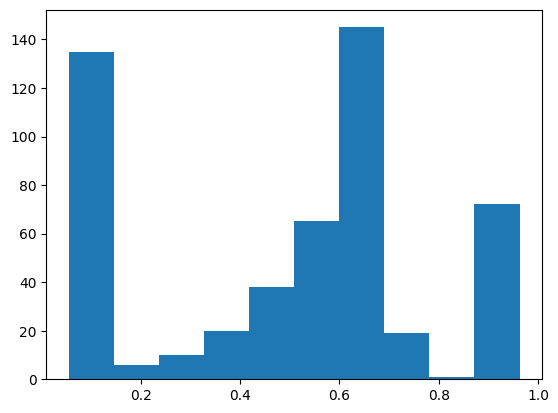

In [31]:
plt.hist(found_df["mean_viability"].values)

In [32]:
merged_viability = found_df[["drug", "cell_line", "mean_viability"]].merge(
    results_df[["drug", "cell_line", "euclidean_dist"]], on=["drug", "cell_line"], how="inner"
).dropna()

r, p = stats.spearmanr(merged_viability["euclidean_dist"], merged_viability["mean_viability"])

In [33]:
r

-0.08570431714221076

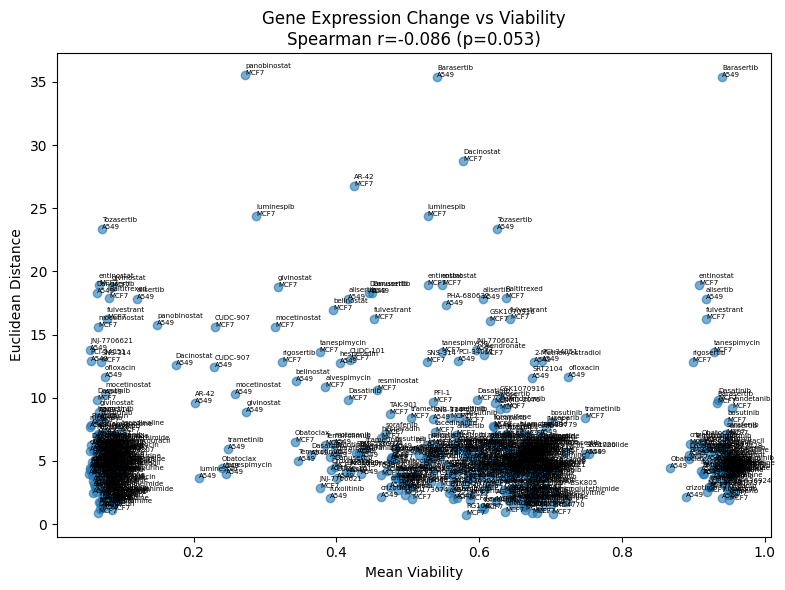

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(merged_viability["mean_viability"], merged_viability["euclidean_dist"], alpha=0.6)
for _, row in merged_viability.iterrows():
    plt.annotate(f"{row['drug']}\n{row['cell_line']}", (row["mean_viability"], row["euclidean_dist"]), fontsize=5)
plt.xlabel("Mean Viability")
plt.ylabel("Euclidean Distance")
plt.title(f"Gene Expression Change vs Viability\nSpearman r={r:.3f} (p={p:.3f})")
plt.tight_layout()
plt.show()

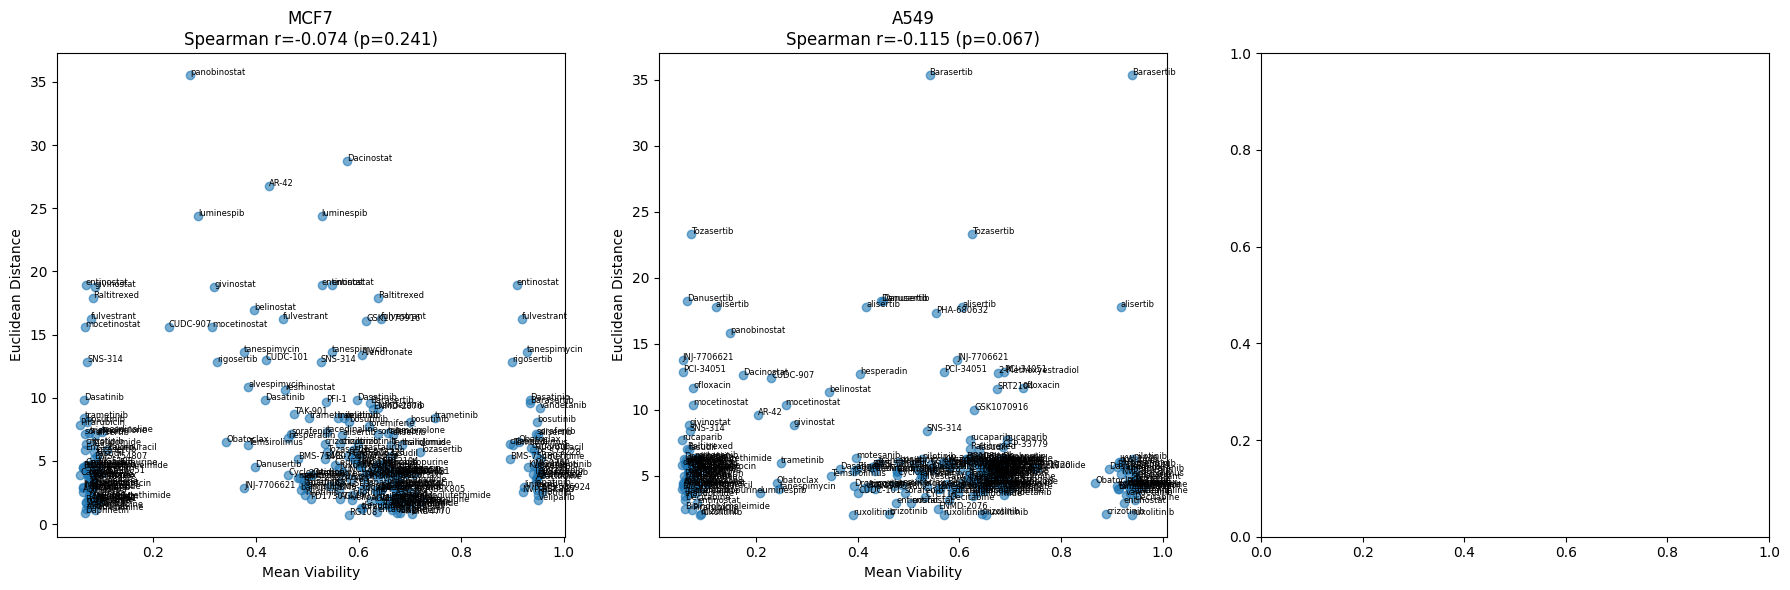

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cell_line in zip(axes, ["MCF7", "A549", "K-562"]):
    subset = merged_viability[merged_viability["cell_line"] == cell_line].dropna()
    if len(subset) < 2:
        continue
    r, p = stats.spearmanr(subset["euclidean_dist"], subset["mean_viability"])
    ax.scatter(subset["mean_viability"], subset["euclidean_dist"], alpha=0.6)
    for _, row in subset.iterrows():
        ax.annotate(row["drug"], (row["mean_viability"], row["euclidean_dist"]), fontsize=6)
    ax.set_xlabel("Mean Viability")
    ax.set_ylabel("Euclidean Distance")
    ax.set_title(f"{cell_line}\nSpearman r={r:.3f} (p={p:.3f})")

plt.tight_layout()
plt.show()

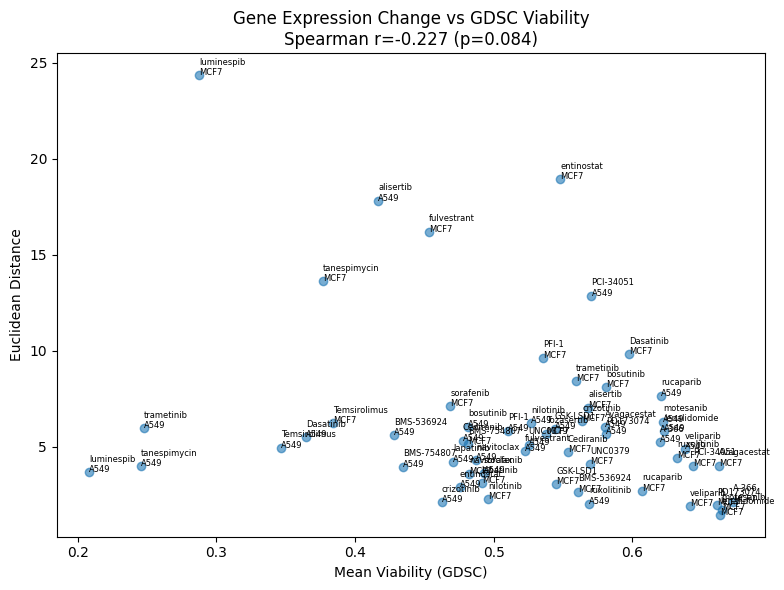

In [36]:
gdsc_viability = found_df[found_df["dataset"] == "GDSC"][["drug", "cell_line", "mean_viability"]]
merged_gdsc = gdsc_viability.merge(results_df[["drug", "cell_line", "euclidean_dist"]], on=["drug", "cell_line"], how="inner").dropna()

r, p = stats.spearmanr(merged_gdsc["euclidean_dist"], merged_gdsc["mean_viability"])
plt.figure(figsize=(8, 6))
plt.scatter(merged_gdsc["mean_viability"], merged_gdsc["euclidean_dist"], alpha=0.6)
for _, row in merged_gdsc.iterrows():
    plt.annotate(f"{row['drug']}\n{row['cell_line']}", (row["mean_viability"], row["euclidean_dist"]), fontsize=6)
plt.xlabel("Mean Viability (GDSC)")
plt.ylabel("Euclidean Distance")
plt.title(f"Gene Expression Change vs GDSC Viability\nSpearman r={r:.3f} (p={p:.3f})")
plt.tight_layout()
plt.show()

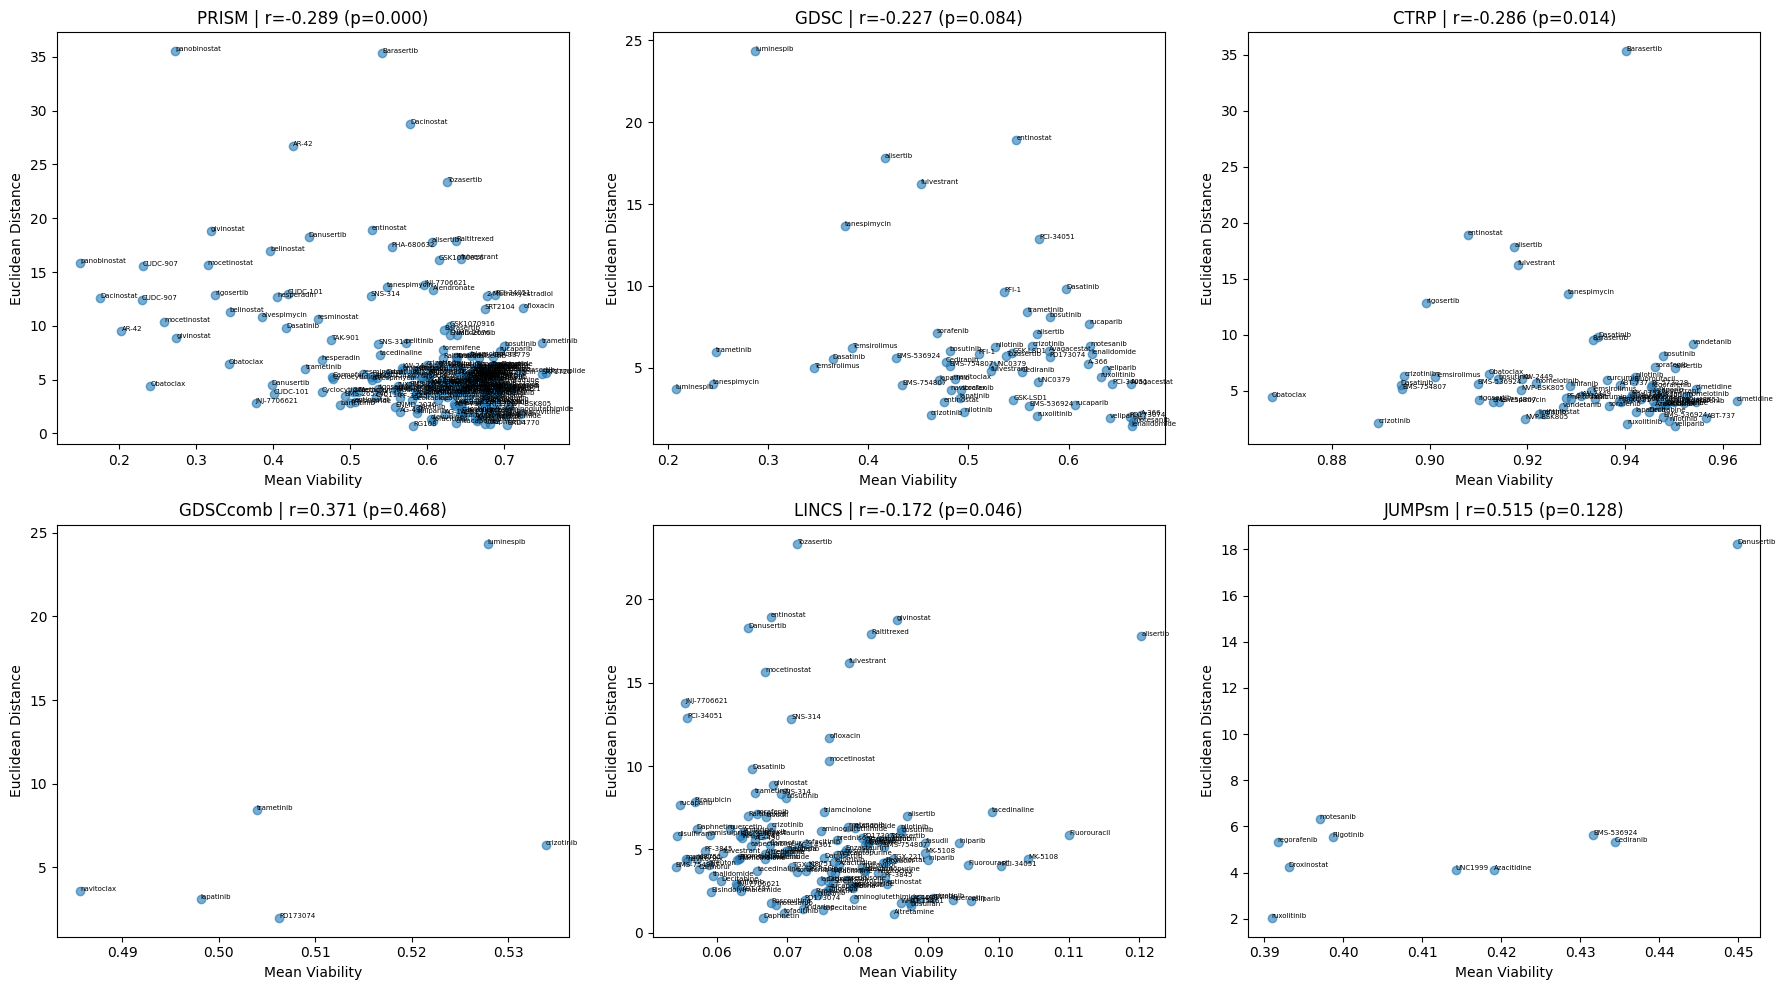

In [37]:
datasets = found_df["dataset"].unique()
n = len(datasets)
fig, axes = plt.subplots(2, (n+1)//2, figsize=(18, 10))
axes = axes.flatten()

for ax, dataset in zip(axes, datasets):
    subset = found_df[found_df["dataset"] == dataset][["drug", "cell_line", "mean_viability"]]
    merged = subset.merge(results_df[["drug", "cell_line", "euclidean_dist"]], on=["drug", "cell_line"], how="inner").dropna()
    if len(merged) < 2:
        continue
    r, p = stats.spearmanr(merged["euclidean_dist"], merged["mean_viability"])
    ax.scatter(merged["mean_viability"], merged["euclidean_dist"], alpha=0.6)
    for _, row in merged.iterrows():
        ax.annotate(f"{row['drug']}", (row["mean_viability"], row["euclidean_dist"]), fontsize=5)
    ax.set_xlabel("Mean Viability")
    ax.set_ylabel("Euclidean Distance")
    ax.set_title(f"{dataset} | r={r:.3f} (p={p:.3f})")

plt.tight_layout()
plt.savefig("corr_all_datasets.png", dpi=150)
plt.show()